# Rayleigh problem with MIDL
 Run `MIDL` to discover dominant dimensionless groups.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf

current_notebook_dir = os.getcwd()
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '..', '..'))
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)

import midl
MIDL = midl.MIDL
calc_basis = midl.calc_basis


In [3]:
 ## Generate dataset for Rayleigh's problem
# Function to compute velocity profile u/U as a function of y and t for fixed U and nu
def velocity_profile_rayleigh(y, nu, U, t):
    return U * (1 - erf(y / (2 * np.sqrt(nu * t))))
# Generate samples in the dataset
y_values        = np.linspace(1e-3, 1, 50)                    # Distance from the plate (m)
t_values        = np.linspace(0.01, 5, 20)                 # Time values (s)
n_samples       = 100                                        # Number of samples for U and nu
U_samples       = np.random.uniform(0.5, 1.0, n_samples)   # Plate velocity (m/s)
nu_samples      = np.random.uniform(1e-3, 1e-2, n_samples) # Kinematic viscosity (m^2/s)
u_list          = []
parameters_list = []

for i in range(n_samples):
    U_current   = U_samples[i]
    nu_current  = nu_samples[i]
    for y in y_values:
        for t in t_values:
            u_value = velocity_profile_rayleigh(y, nu_current, U_current, t)
            u_list.append(u_value)
            parameters_list.append([U_current, y, t, nu_current])
u_array          = np.array(u_list).reshape(-1, 1)  
parameters_array = np.array(parameters_list)



In [4]:
## Replace with your own input, dimensionless output, dimension matrix and variable name
Y                = u_array/parameters_array[:,0].reshape(-1,1)  #Output \Pi_o
X_raw                = parameters_array                             #Dimensional input list q                         
D_in             = np.matrix('1 1 0 2;-1 0 1 -1')               #Define D_in matrix, first row "L",second row "T"

# Compute basis and construct independent dimensionless groups Pi
basis, r = calc_basis(D_in)
print('Null space dimension:', D_in.shape[1] - r)
print('basis:\n', basis)

Pi = np.exp(np.log(X_raw) @ basis)

Null space dimension: 2
basis:
 [[ 0.43670068 -0.68989795]
 [-0.68989795 -0.43670068]
 [ 0.56329932 -0.12659863]
 [ 0.12659863  0.56329932]]


/var/folders/pb/r9pcy0td7t1dvrds4bzfmgch0000gn/T/ipykernel_81313/3240714937.py:11: RuntimeWarning: divide by zero encountered in matmul
  Pi = np.exp(np.log(X_raw) @ basis)
/var/folders/pb/r9pcy0td7t1dvrds4bzfmgch0000gn/T/ipykernel_81313/3240714937.py:11: RuntimeWarning: overflow encountered in matmul
  Pi = np.exp(np.log(X_raw) @ basis)
/var/folders/pb/r9pcy0td7t1dvrds4bzfmgch0000gn/T/ipykernel_81313/3240714937.py:11: RuntimeWarning: invalid value encountered in matmul
  Pi = np.exp(np.log(X_raw) @ basis)


In [5]:
# Run MIDL
model = MIDL(
    k_neighbors=6,
    de_maxiter=200,
    random_state=42,
)

result = model.fit(Pi_independent=Pi, pi_dependent=Y, threshold=10)
pi_hat = MIDL.compose_new_pi(Pi, result['W'])

print('\n=== MIDL Results ===')
print('MI scores:', result['mi_scores'])
print('dominant_q:', result['dominant_q'])
print('drop ratios I_i / I_(i+1):', result['drop_ratios'])

# Exponents in original variable space
alpha = basis @ result['W']
print('\n=== Recovered exponents in original variables ===')
print(alpha)


[Step 1] MI = 5.314194
[Step 2] MI = 0.365050
   ratio = 14.557
   >>> Early stopping triggered at step 2

=== MIDL Results ===
MI scores: [5.31419362]
dominant_q: 1
drop ratios I_i / I_(i+1): 14.557434001113998

=== Recovered exponents in original variables ===
[[-7.56901313e-06]
 [ 8.16496581e-01]
 [-4.08252075e-01]
 [-4.08244506e-01]]


/Users/baoyuan/Desktop/MI_DL/midl.py:178: RuntimeWarning: divide by zero encountered in matmul
  xhat = X @ W
/Users/baoyuan/Desktop/MI_DL/midl.py:178: RuntimeWarning: overflow encountered in matmul
  xhat = X @ W
/Users/baoyuan/Desktop/MI_DL/midl.py:178: RuntimeWarning: invalid value encountered in matmul
  xhat = X @ W
/Users/baoyuan/Desktop/MI_DL/midl.py:193: RuntimeWarning: divide by zero encountered in matmul
  xhat = X @ W
/Users/baoyuan/Desktop/MI_DL/midl.py:193: RuntimeWarning: overflow encountered in matmul
  xhat = X @ W
/Users/baoyuan/Desktop/MI_DL/midl.py:193: RuntimeWarning: invalid value encountered in matmul
  xhat = X @ W


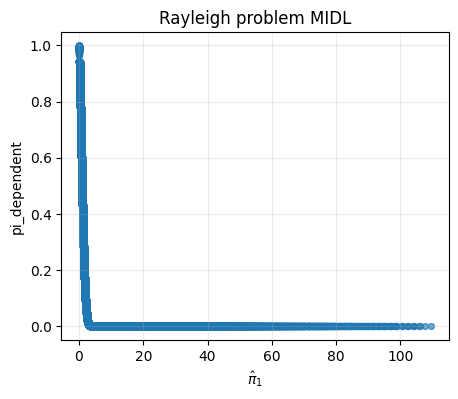

In [6]:
# Plot: 2D always, and extra 3D when dominant_q >= 2
if result['dominant_q'] >= 2:
    ax2d, ax3d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Rayleigh problem MIDL',
        log_scale=False,
    )
else:
    ax2d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=Y,
        W=result['W'],
        dominant_q=result['dominant_q'],
        component_index=0,
        title='Rayleigh problem MIDL',
        log_scale=False,
    )
plt.show()
